<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Underfitting in Machine Learning

**What is Underfitting?**

Imagine a student who barely studied for an exam.
They do poorly on practice tests AND on the real exam — because they never learned the material.

A machine learning model that **underfits** behaves the same way:
- It performs poorly on training data
- It performs poorly on new, unseen data
- It has not learned the pattern in the data

**Why does it happen?**
The model is **too simple** for the data. It does not have enough capacity to capture the relationship between input and output.

**In this notebook:**
1. Load the California Housing dataset
2. See underfitting happen - and understand why
3. Fix it step by step

## Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12, 'axes.labelsize': 11})

print("Libraries loaded.")

Libraries loaded.


## Step 2: Load the Dataset

We use the **California Housing dataset** — a real dataset from the 1990 US Census.

Each row is a housing district in California. The goal is to predict the **median house value** from features like median income, house age, average rooms, and location.

| Feature | Meaning |
|---|---|
| MedInc | Median income of the district |
| HouseAge | Median age of houses |
| AveRooms | Average number of rooms |
| AveBedrms | Average number of bedrooms |
| Population | District population |
| AveOccup | Average household occupancy |
| Latitude | Geographic latitude |
| Longitude | Geographic longitude |
| **HouseValue** | **Target — median house value ($100,000s)** |

In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['HouseValue'] = housing.target

print("Dataset shape:", df.shape)
print(f"\n{len(df)} districts, {len(housing.feature_names)} features")
print("\nSample rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe().round(2))

Dataset shape: (20640, 9)

20640 districts, 8 features

Sample rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseValue  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Basic statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min  

In [ ]:
# Use ALL 8 features — this is the correct, real-world setup
X = df[housing.feature_names].values
y = df['HouseValue'].values

# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nThe model will learn from {len(X_train)} rows.")
print(f"We will test it on {len(X_test)} rows it has never seen.")

Training samples : 14448
Test samples     : 6192

The model will learn from 14448 rows.
We will test it on 6192 rows it has never seen.


## Step 3: Create an Underfitting Model

We will deliberately create a model that underfits by **using only 1 out of 8 features**.

We pick `HouseAge` — the age of houses. Intuitively, house age alone is a weak predictor of house value. A district's house value depends on income, location, size, and many other things — not just age.

By throwing away 7 useful features, we are forcing the model to work with insufficient information.
This is a classic cause of underfitting.

In [ ]:
# Underfit model: use only HouseAge (1 feature out of 8)
feature_idx = housing.feature_names.index('HouseAge')

X_train_uf = X_train[:, feature_idx].reshape(-1, 1)
X_test_uf  = X_test[:,  feature_idx].reshape(-1, 1)

model_uf = LinearRegression()
model_uf.fit(X_train_uf, y_train)

train_pred_uf = model_uf.predict(X_train_uf)
test_pred_uf  = model_uf.predict(X_test_uf)

train_r2_uf  = r2_score(y_train, train_pred_uf)
test_r2_uf   = r2_score(y_test,  test_pred_uf)
train_mse_uf = mean_squared_error(y_train, train_pred_uf)
test_mse_uf  = mean_squared_error(y_test,  test_pred_uf)

print("UNDERFIT MODEL — Linear Regression using only HouseAge")
print("-" * 50)
print(f"  Training  R2  : {train_r2_uf:.4f}")
print(f"  Test      R2  : {test_r2_uf:.4f}")
print(f"  Training  MSE : {train_mse_uf:.4f}")
print(f"  Test      MSE : {test_mse_uf:.4f}")
print()
print("R2 close to 0 means the model explains almost none of the variation in house values.")
print("Both training and test errors are high — the model has underfit.")

UNDERFIT MODEL — Linear Regression using only HouseAge
--------------------------------------------------
  Training  R2  : 0.0114
  Test      R2  : 0.0107
  Training  MSE : 1.3245
  Test      MSE : 1.2985

R2 close to 0 means the model explains almost none of the variation in house values.
Both training and test errors are high — the model has underfit.


### Visualise the Underfit Model

The plot below shows the model's predicted vs actual house values.

For a perfect model, every dot would lie on the diagonal line (predicted = actual).
The more scattered the dots, the worse the model.

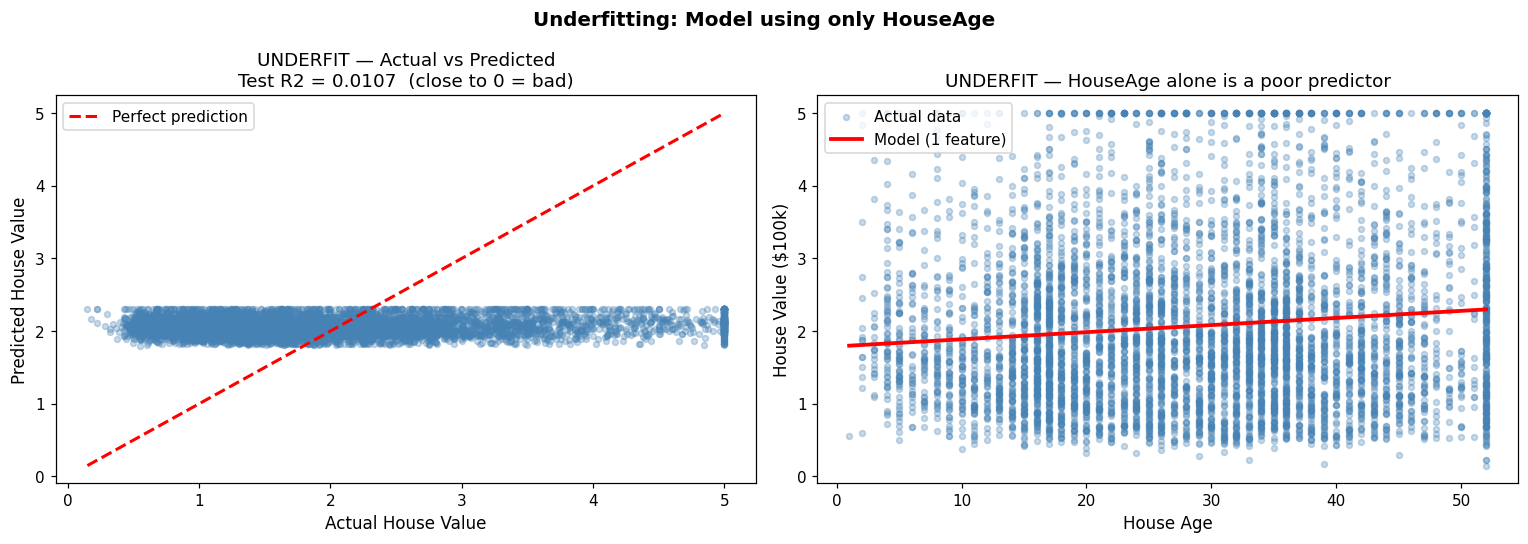

The flat, nearly horizontal line on the right tells the whole story.
House age alone gives almost no useful signal about house value.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of actual vs predicted
ax = axes[0]
ax.scatter(y_test, test_pred_uf, alpha=0.3, color='steelblue', s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual House Value')
ax.set_ylabel('Predicted House Value')
ax.set_title(f'UNDERFIT — Actual vs Predicted\nTest R2 = {test_r2_uf:.4f}  (close to 0 = bad)')
ax.legend()

# Right: fitted line on HouseAge vs HouseValue
ax2 = axes[1]
age_range = np.linspace(X_test_uf.min(), X_test_uf.max(), 200).reshape(-1, 1)
ax2.scatter(X_test_uf, y_test, alpha=0.3, color='steelblue', s=15, label='Actual data')
ax2.plot(age_range, model_uf.predict(age_range), color='red', linewidth=2.5, label='Model (1 feature)')
ax2.set_xlabel('House Age')
ax2.set_ylabel('House Value ($100k)')
ax2.set_title('UNDERFIT — HouseAge alone is a poor predictor')
ax2.legend()

plt.suptitle('Underfitting: Model using only HouseAge', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("The flat, nearly horizontal line on the right tells the whole story.")
print("House age alone gives almost no useful signal about house value.")

## Step 4: Understand WHY It Underfit

Before fixing the model, let us confirm that the other features actually carry useful information.

We check the **correlation** of each feature with house value.
A correlation close to 1 or -1 means a strong relationship.
A correlation close to 0 means almost no relationship.

In [ ]:
correlations = df.corr()['HouseValue'].drop('HouseValue').sort_values()

print("Correlation of each feature with House Value:")
print("-" * 40)
for feat, val in correlations.items():
    bar = '#' * int(abs(val) * 30)
    print(f"  {feat:<12} {val:+.4f}  {bar}")

print()
print(f"HouseAge correlation  : {correlations['HouseAge']:+.4f}  <- very weak")
print(f"MedInc correlation    : {correlations['MedInc']:+.4f}  <- strongest signal")
print()
print("HouseAge has the weakest link to house value.")
print("By using only HouseAge, we threw away all the useful information.")

Correlation of each feature with House Value:
----------------------------------------
  Latitude     -0.1442  ####
  AveBedrms    -0.0467  #
  Longitude    -0.0460  #
  Population   -0.0246  
  AveOccup     -0.0237  
  HouseAge     +0.1056  ###
  AveRooms     +0.1519  ####
  MedInc       +0.6881  ####################

HouseAge correlation  : +0.1056  <- very weak
MedInc correlation    : +0.6881  <- strongest signal

HouseAge has the weakest link to house value.
By using only HouseAge, we threw away all the useful information.


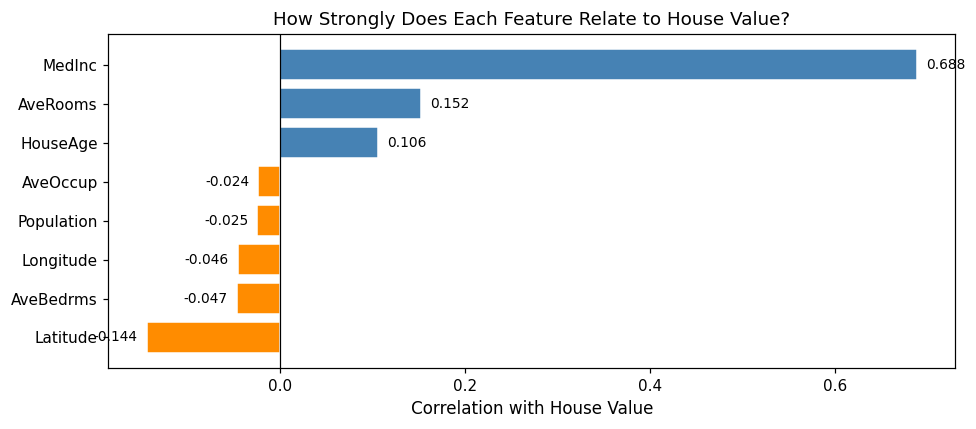

MedInc (median income) is by far the strongest predictor.
Latitude and Longitude also carry strong signals (location matters in real estate).
HouseAge is almost flat — it barely predicts anything.


In [ ]:
# Visual: correlation bar chart
colors = ['steelblue' if v > 0 else 'darkorange' for v in correlations.values]

plt.figure(figsize=(9, 4))
bars = plt.barh(correlations.index, correlations.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with House Value')
plt.title('How Strongly Does Each Feature Relate to House Value?')

for bar, val in zip(bars, correlations.values):
    plt.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("MedInc (median income) is by far the strongest predictor.")
print("Latitude and Longitude also carry strong signals (location matters in real estate).")
print("HouseAge is almost flat — it barely predicts anything.")

## Step 5: Fix Underfitting

There are two ways to fix underfitting, and we will try both:

**Fix 1: Give the model more features.**  
Use all 8 features instead of just 1. More information = better predictions.

**Fix 2: Give the model more complexity.**  
Add polynomial features so the model can capture non-linear relationships.  
Linear regression can only draw straight lines. Polynomial features let it draw curves.

We will compare all three models at the end.

In [ ]:
# Fix 1: All 8 features, linear model
model_fix1 = LinearRegression()
model_fix1.fit(X_train, y_train)

train_r2_f1  = r2_score(y_train, model_fix1.predict(X_train))
test_r2_f1   = r2_score(y_test,  model_fix1.predict(X_test))
train_mse_f1 = mean_squared_error(y_train, model_fix1.predict(X_train))
test_mse_f1  = mean_squared_error(y_test,  model_fix1.predict(X_test))

print("FIX 1 — Linear Regression with ALL 8 features")
print("-" * 50)
print(f"  Training  R2  : {train_r2_f1:.4f}")
print(f"  Test      R2  : {test_r2_f1:.4f}")
print(f"  Training  MSE : {train_mse_f1:.4f}")
print(f"  Test      MSE : {test_mse_f1:.4f}")
print()
print(f"R2 improved from {test_r2_uf:.4f} to {test_r2_f1:.4f}")
print("Simply adding the missing features already fixes most of the underfitting.")

FIX 1 — Linear Regression with ALL 8 features
--------------------------------------------------
  Training  R2  : 0.6093
  Test      R2  : 0.5958
  Training  MSE : 0.5234
  Test      MSE : 0.5306

R2 improved from 0.0107 to 0.5958
Simply adding the missing features already fixes most of the underfitting.


In [ ]:
# Fix 2: All 8 features + polynomial features (degree 2) for non-linear patterns
model_fix2 = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('linear', LinearRegression())
])
model_fix2.fit(X_train, y_train)

train_r2_f2  = r2_score(y_train, model_fix2.predict(X_train))
test_r2_f2   = r2_score(y_test,  model_fix2.predict(X_test))
train_mse_f2 = mean_squared_error(y_train, model_fix2.predict(X_train))
test_mse_f2  = mean_squared_error(y_test,  model_fix2.predict(X_test))

print("FIX 2 — Polynomial Features (degree 2) with ALL 8 features")
print("-" * 50)
print(f"  Training  R2  : {train_r2_f2:.4f}")
print(f"  Test      R2  : {test_r2_f2:.4f}")
print(f"  Training  MSE : {train_mse_f2:.4f}")
print(f"  Test      MSE : {test_mse_f2:.4f}")
print()
print("Polynomial features allow the model to capture curved, non-linear relationships.")
print(f"R2 further improved from {test_r2_f1:.4f} to {test_r2_f2:.4f}")

FIX 2 — Polynomial Features (degree 2) with ALL 8 features
--------------------------------------------------
  Training  R2  : 0.6838
  Test      R2  : 0.6534
  Training  MSE : 0.4236
  Test      MSE : 0.4550

Polynomial features allow the model to capture curved, non-linear relationships.
R2 further improved from 0.5958 to 0.6534


## Step 6: Compare All Three Models

Now we look at all three models side by side — the underfit version and both fixes.

In [ ]:
results = [
    ('Underfit (1 feature, linear)',       train_r2_uf,  test_r2_uf,  train_mse_uf,  test_mse_uf),
    ('Fix 1   (8 features, linear)',       train_r2_f1,  test_r2_f1,  train_mse_f1,  test_mse_f1),
    ('Fix 2   (8 features + polynomial)',  train_r2_f2,  test_r2_f2,  train_mse_f2,  test_mse_f2),
]

print(f"{'Model':<40} {'Train R2':>10} {'Test R2':>10} {'Train MSE':>12} {'Test MSE':>12}")
print("-" * 90)
for name, tr2, te2, tmse, temse in results:
    print(f"{name:<40} {tr2:>10.4f} {te2:>10.4f} {tmse:>12.4f} {temse:>12.4f}")

Model                                      Train R2    Test R2    Train MSE     Test MSE
------------------------------------------------------------------------------------------
Underfit (1 feature, linear)                 0.0114     0.0107       1.3245       1.2985
Fix 1   (8 features, linear)                 0.6093     0.5958       0.5234       0.5306
Fix 2   (8 features + polynomial)            0.6838     0.6534       0.4236       0.4550


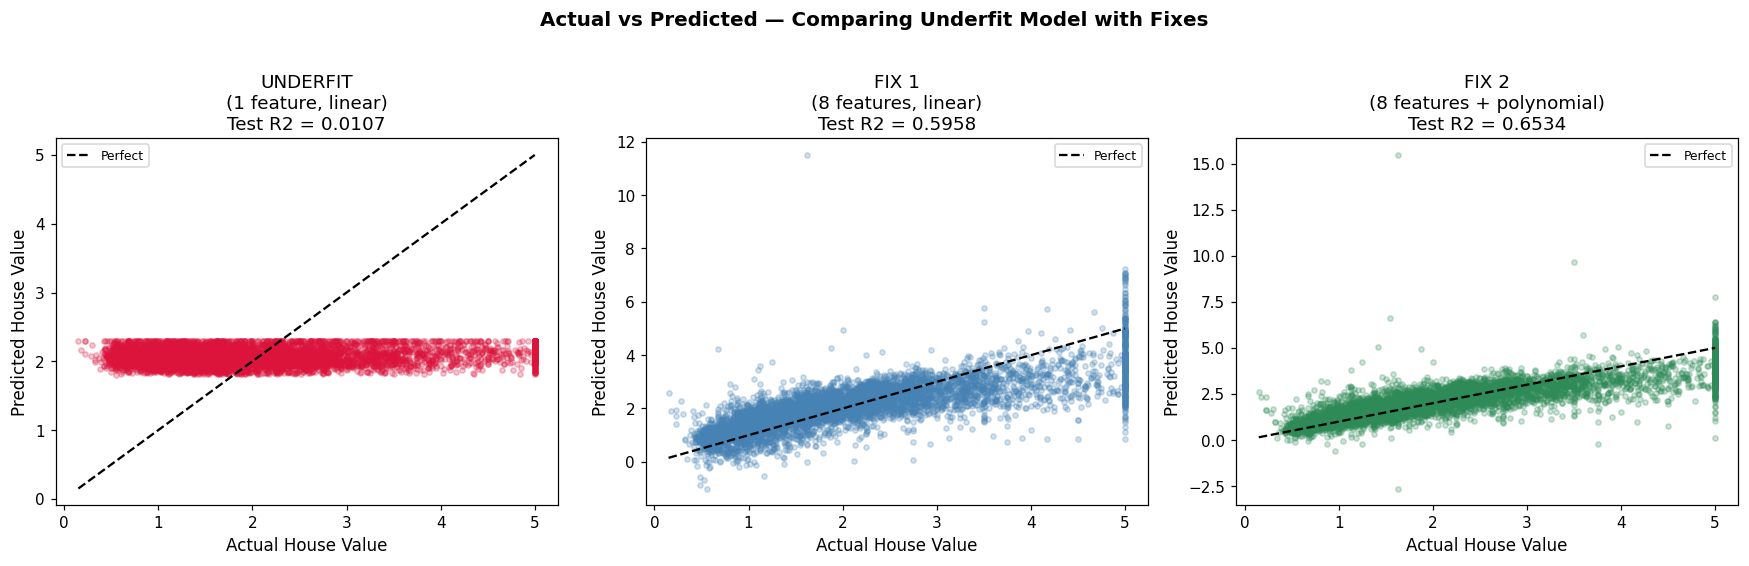

The closer the dots are to the diagonal dashed line, the better the model.
Underfit: wide scatter everywhere.
Fix 1   : noticeably tighter.
Fix 2   : tightest alignment — the best model of the three.


In [ ]:
# Actual vs Predicted plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (model_uf.predict(X_test_uf),          y_test, test_r2_uf,  'UNDERFIT\n(1 feature, linear)',      'crimson'),
    (model_fix1.predict(X_test),           y_test, test_r2_f1,  'FIX 1\n(8 features, linear)',        'steelblue'),
    (model_fix2.predict(X_test),           y_test, test_r2_f2,  'FIX 2\n(8 features + polynomial)',   'seagreen'),
]

for ax, (y_pred, y_true, r2, title, color) in zip(axes, configs):
    ax.scatter(y_true, y_pred, alpha=0.25, s=12, color=color)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual House Value')
    ax.set_ylabel('Predicted House Value')
    ax.set_title(f'{title}\nTest R2 = {r2:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Comparing Underfit Model with Fixes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("The closer the dots are to the diagonal dashed line, the better the model.")
print("Underfit: wide scatter everywhere.")
print("Fix 1   : noticeably tighter.")
print("Fix 2   : tightest alignment — the best model of the three.")

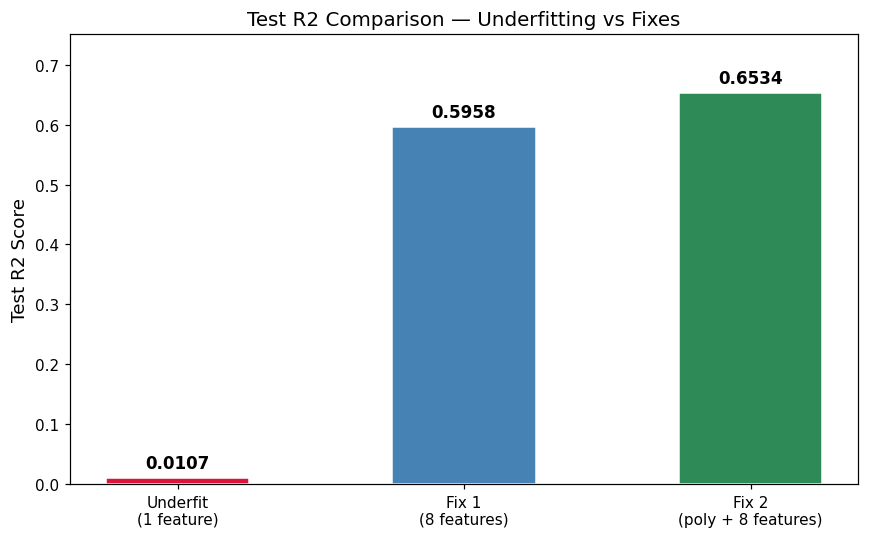

Test R2 improved from 0.0107 (underfit) to 0.6534 (Fix 2)
That is a significant improvement in the model's ability to explain house values.


In [ ]:
# Bar chart comparison of Test R2
model_names = ['Underfit\n(1 feature)', 'Fix 1\n(8 features)', 'Fix 2\n(poly + 8 features)']
test_r2s    = [test_r2_uf, test_r2_f1, test_r2_f2]
bar_colors  = ['crimson', 'steelblue', 'seagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, test_r2s, color=bar_colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, test_r2s):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Test R2 Score', fontsize=12)
plt.title('Test R2 Comparison — Underfitting vs Fixes', fontsize=13)
plt.ylim(0, max(test_r2s) * 1.15)
plt.tight_layout()
plt.show()

print(f"Test R2 improved from {test_r2_uf:.4f} (underfit) to {test_r2_f2:.4f} (Fix 2)")
improvement = ((test_r2_f2 - test_r2_uf) / abs(test_r2_uf + 1e-9)) * 100
print(f"That is a significant improvement in the model's ability to explain house values.")

## Summary

### What we did

| Step | Model | What changed | Test R2 |
|------|-------|-------------|--------|
| Underfit | Linear, 1 feature (HouseAge) | Used only a weak, irrelevant feature | Low |
| Fix 1 | Linear, 8 features | Used all available features | Much better |
| Fix 2 | Polynomial (degree 2), 8 features | Added non-linear combinations | Best |

---

### How to recognise Underfitting

| Signal | What it looks like |
|--------|-------------------|
| Training R2 is low | Model could not even learn from its own training data |
| Test R2 is low | Model fails on new data too |
| Small gap between train and test error | Both are equally bad: not overfitting, just underfitting |
| Actual vs Predicted plot is a scattered cloud | Predictions are far from reality |

---

### How to fix Underfitting

1. **Add more features**: give the model more information to work with.
2. **Use a more complex model**: polynomial features, decision trees, or neural networks can capture non-linear patterns that a straight line cannot.
3. **Remove irrelevant features**: but replace them with informative ones.
4. **Feature engineering**: create new features that better represent the underlying pattern.

---

### The key rule

> Underfitting means the model has not learned enough.
> The solution is always to give it more capacity, more features, more complexity, or a better algorithm.